<a href="https://colab.research.google.com/github/biancadsouza-21/computational-statistics/blob/main/CSSL_08_logistic_regression_and_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic regression

In [1]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline

In [2]:
iris = load_iris()
X_raw = iris.data[:, :4]
y_raw = iris.target
type(X_raw)

numpy.ndarray

Perform Logisitic Regression and kNN on this dataset following the below steps:

1.  Preprocess the data
    * Check for empty values or nulls and perform necessary imputations/deletions
    * Encode the class variable numerically using the label encoder, if necessary
    * Scale features as necessary
2. Logistic regression
    * Split the data into train and test sets
    * Create a logistic regression model by selecting any two features
    * Fit the logistic regression model to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.
3. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay
4. kNN
    * Create a kNN model by selecting any two features
    * Fit the kNN to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.
5. Plotting the decision boundaries for kNN
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay
6. Build a Logistic regression model and KNN using all features and compare their performance by creating confusion matrix and getting classification reports.
7. Add polynomial features to the logistic regression model and check its performance

Let's try to visualize the dataset

In [4]:
print(iris)
print(X_raw.shape)
print(y_raw.shape)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

It appear the dataset has 3 classes: setosa, versicolor and virginica, which correspond to 3 species of flowers. The features provided include: sepal length, sepal width, petal length and petal width. The model needs to classify which species the flower belongs to based on these features. We have around 150 data points in this dataset.

## 1. Preprocessing

In [5]:
# Check for empty values
X_nan_indices = np.where(np.isnan(X_raw))
print(f"Indices with nans in X = {X_nan_indices}")
y_nan_indices = np.where(np.isnan(y_raw))
print(f"Indices with nans in y = {y_nan_indices}")

Indices with nans in X = (array([], dtype=int64), array([], dtype=int64))
Indices with nans in y = (array([], dtype=int64),)


It appears that there are no nans in both X and y. This step could have been done by converting the data to a pandas DataFrame as well. Either approach is okay.

In [6]:
# Check whether the y values require numerical encoding
print(y_raw)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Since the y values are already encoded numerically, we don't have to do anything. We can directly use y=y_raw. Otherwise we'd have do the below commented steps.

In [ ]:
# To encode y values numerically using the Label Encoder, you will need to uncomment the below lines.
# le = LabelEncoder()
# y = le.fit_transform(y_raw)
# print(y)

In [7]:
y = y_raw # If you perform label encoding using the steps mentioned in the above cell, you shouldn't do this step. We are doing this only because our raw y values were already encoded.

In [8]:
# Feature Scaling
# Since at some point, we plan to integrate polynomial features as well, let us just use min-max scaling.
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)
print(X)

[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]
 [0.30555556 0.79166667 0.11864407 0.125     ]
 [0.08333333 0.58333333 0.06779661 0.08333333]
 [0.19444444 0.58333333 0.08474576 0.04166667]
 [0.02777778 0.375      0.06779661 0.04166667]
 [0.16666667 0.45833333 0.08474576 0.        ]
 [0.30555556 0.70833333 0.08474576 0.04166667]
 [0.13888889 0.58333333 0.10169492 0.04166667]
 [0.13888889 0.41666667 0.06779661 0.        ]
 [0.         0.41666667 0.01694915 0.        ]
 [0.41666667 0.83333333 0.03389831 0.04166667]
 [0.38888889 1.         0.08474576 0.125     ]
 [0.30555556 0.79166667 0.05084746 0.125     ]
 [0.22222222 0.625      0.06779661 0.08333333]
 [0.38888889 0.75       0.11864407 0.08333333]
 [0.22222222 0.75       0.08474576 0.08333333]
 [0.30555556 0.58333333 0.11864407 0.04166667]
 [0.22222222 

## 2. Logistic Regression

Let's perform logisitic regression using just the first two features. Ideally we should use all features, which we will do at a later stage. At this stage we want to visualize how the decision boundaries look, which can only be done in 2 dimensions. Hence we need to pick only 2 features.

In [9]:
# Select any two features. I'm choosing the last two features, i.e., petal length and petal width
X_subset = X[:, 2:4]

# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.3, random_state=287)

# Create a logistic regression model and fit the data
model = LogisticRegression()
model.fit(X_train, y_train)

# Get predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## 3. Plotting decision boundaries

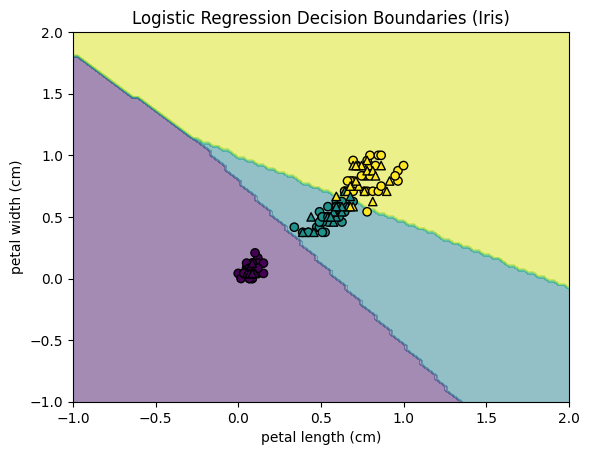

In [19]:
# Plot decision boundaries
disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X_subset,
    response_method="predict",
    xlabel=iris.feature_names[2], # Fetching the feature names from original dataset. You can directly mention it as a string as well, i.e., "petal length"
    ylabel=iris.feature_names[3],
    alpha=0.5,
)

# 4. Overlay the actual data points
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k") # Train data
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", marker = "^") # Test data
plt.title("Logistic Regression Decision Boundaries (Iris)")
plt.show()

By just glancing at the decision boundaries, it appears that the logistic regression model is doing decently well. However we will need to compare the actual metrics to be certain about this.

# KNN

## 4. KNN model

Now let's try fitting the KNN model on the same data. We just need to copy paste the above 2 code cells and only change two lines, the model and the plot title. You can specify the number of neighbours if you wish to.

In [33]:
# Select any two features. I'm choosing the last two features, i.e., petal length and petal width
X_subset = X[:, 2:4]

# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.3, random_state=287)

# Create a KNN model and fit the data
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Get predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## 5. Plotting decision boundaries

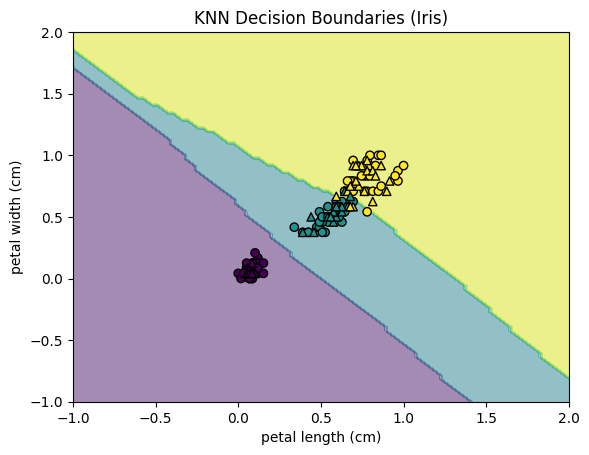

In [34]:
# Plot decision boundaries
disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X_subset,
    response_method="predict",
    xlabel=iris.feature_names[2], # Fetching the feature names from original dataset. You can directly mention it as a string as well, i.e., "petal length"
    ylabel=iris.feature_names[3],
    alpha=0.5,
)

# 4. Overlay the actual data points
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k") # Train data
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", marker = "^") # Test data
plt.title("KNN Decision Boundaries (Iris)")
plt.show()

Notice how Logistic Regression produced linear decision boundaries since it is a linear method, whereas KNN produces non-linear curved boundaries. KNN essentially only looks at the immediate neighbourhood.

### Homework - Try changing k, i.e., the n_neighbours value and plotting the test_error = (1-test_set_accuracy) against k. You'll notice the bias-variance tradeoff kick in.

At very low values of k, the model overfits, because the model cares only about the nearest neighbours and is too affected by the details. At very large k, the model becomes too simplistic and starts listening to too many neighbours, at which point, it will mostly be predicting the majority class for every new test data point.

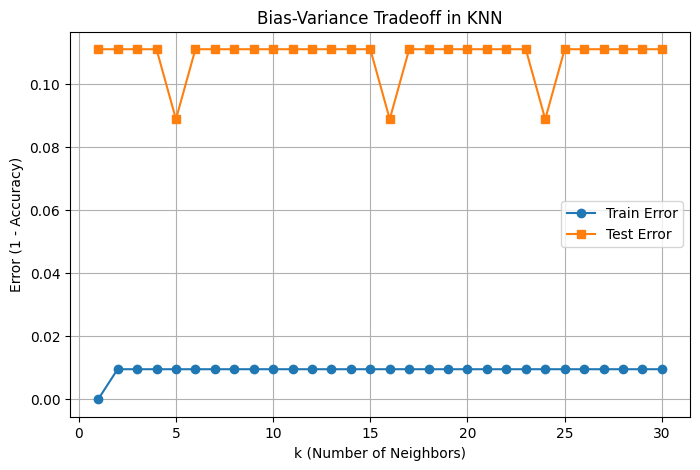

Best k: 5


In [36]:
k_values = range(1, 31)  # Try k from 1 to 30
test_errors = []
train_errors = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    # Accuracy
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    # Error = 1 - accuracy
    train_errors.append(1 - train_acc)
    test_errors.append(1 - test_acc)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_errors, label="Train Error", marker='o')
plt.plot(k_values, test_errors, label="Test Error", marker='s')

plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Bias-Variance Tradeoff in KNN")
plt.legend()
plt.grid()
plt.show()
best_k = k_values[np.argmin(test_errors)]
print("Best k:", best_k)

# 6. Logistic Regression vs KNN for all 4 features together

In [ ]:
# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=287) # Use all features

LOGISTIC REGRESSION
Train set report
Train set accuracy = 0.9523809523809523
Train set f1 score = 0.9524159064163958
Train set classification report =               precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.94      0.91      0.93        34
           2       0.90      0.93      0.92        30

    accuracy                           0.95       105
   macro avg       0.95      0.95      0.95       105
weighted avg       0.95      0.95      0.95       105


Test set report
Test set accuracy = 0.8222222222222222
Test set f1 score = 0.8205291005291006
Test set classification report =               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.79      0.69      0.73        16
           2       0.77      0.85      0.81        20

    accuracy                           0.82        45
   macro avg       0.85      0.85      0.85        45
weighted avg  

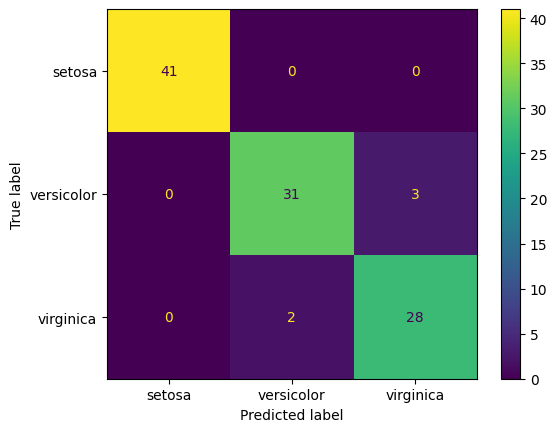

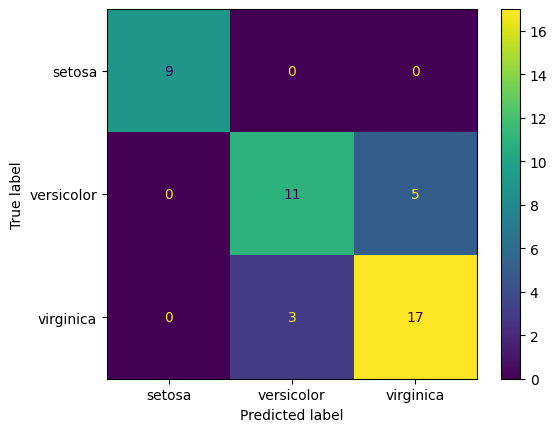

In [ ]:
# Create a logistic regression model and fit the data
model = LogisticRegression()
model.fit(X_train, y_train)

# Get predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
print("LOGISTIC REGRESSION")
print("===================")
print("Train set report")
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train set accuracy = {train_accuracy}")
train_f1_score = f1_score(y_train, y_train_pred, average="weighted")
print(f"Train set f1 score = {train_f1_score}")
train_cr = classification_report(y_train, y_train_pred)
print(f"Train set classification report = {train_cr}")
cm = confusion_matrix(y_train, y_train_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()
print()

print("Test set report")
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set accuracy = {test_accuracy}")
test_f1_score = f1_score(y_test, y_test_pred, average="weighted")
print(f"Test set f1 score = {test_f1_score}")
test_cr = classification_report(y_test, y_test_pred)
print(f"Test set classification report = {test_cr}")
cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()

KNN
Train set report
Train set accuracy = 0.9809523809523809
Train set f1 score = 0.9809523809523809
Train set classification report =               precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.97      0.97      0.97        34
           2       0.97      0.97      0.97        30

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105


Test set report
Test set accuracy = 0.8888888888888888
Test set f1 score = 0.8891478891478892
Test set classification report =               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.82      0.88      0.85        16
           2       0.89      0.85      0.87        20

    accuracy                           0.89        45
   macro avg       0.91      0.91      0.91        45
weighted avg       0.89      0

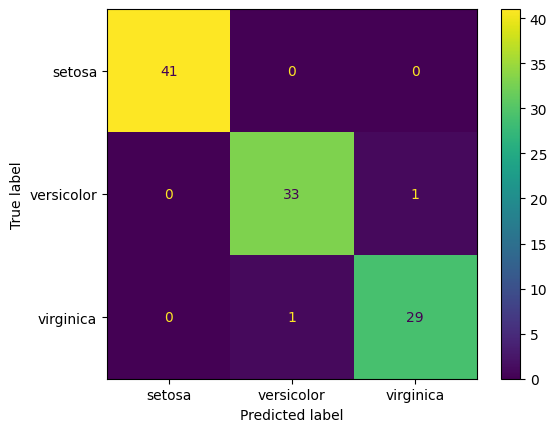

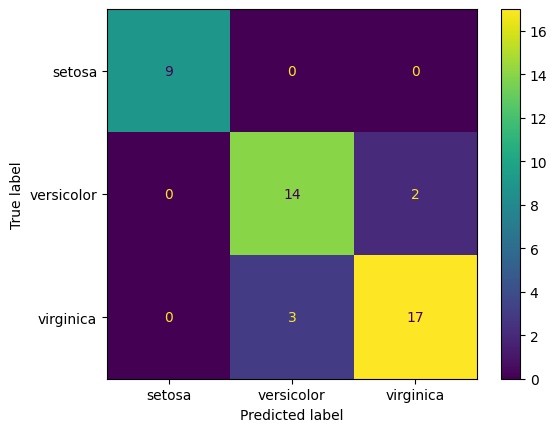

In [ ]:
# Create a KNN model and fit the data
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Get predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
print("KNN")
print("===================")
print("Train set report")
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train set accuracy = {train_accuracy}")
train_f1_score = f1_score(y_train, y_train_pred, average="weighted")
print(f"Train set f1 score = {train_f1_score}")
train_cr = classification_report(y_train, y_train_pred)
print(f"Train set classification report = {train_cr}")
cm = confusion_matrix(y_train, y_train_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()
print()

print("Test set report")
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set accuracy = {test_accuracy}")
test_f1_score = f1_score(y_test, y_test_pred, average="weighted")
print(f"Test set f1 score = {test_f1_score}")
test_cr = classification_report(y_test, y_test_pred)
print(f"Test set classification report = {test_cr}")
cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()

If you compare the test f1_scores, with K=5, the KNN model is performing slightly better than the Logistic Regression model. Perhaps this is because the data is not linearly separable.

Let's try adding some polynomial features to the Logistic regression model and see if it performs better.

# 7. Logistic regression with polynomial features

In [ ]:
# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=287) # Use all features

LOGISTIC REGRESSION WITH POLYNOMIAL FEATURES
Train set report
Train set accuracy = 0.9904761904761905
Train set f1 score = 0.9904644933384801
Train set classification report =               precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.97      1.00      0.99        34
           2       1.00      0.97      0.98        30

    accuracy                           0.99       105
   macro avg       0.99      0.99      0.99       105
weighted avg       0.99      0.99      0.99       105


Test set report
Test set accuracy = 0.8888888888888888
Test set f1 score = 0.8891478891478892
Test set classification report =               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.82      0.88      0.85        16
           2       0.89      0.85      0.87        20

    accuracy                           0.89        45
   macro avg       0.91      0.91      0.91

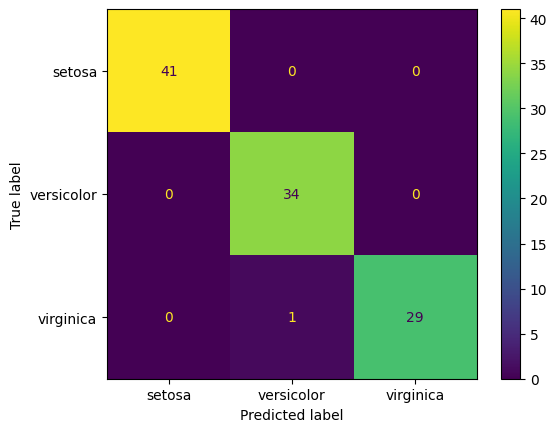

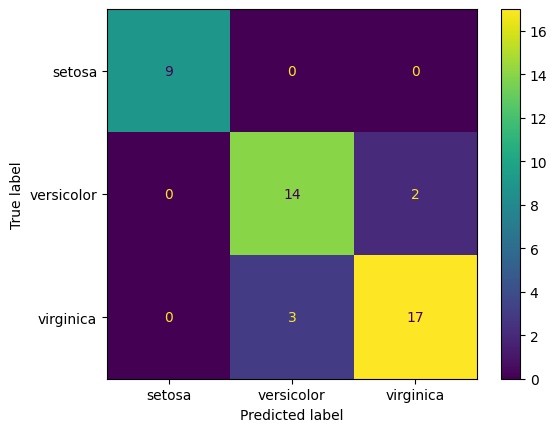

In [ ]:
# Let's build a pipeline to add polynomial features. This just makes our life easier.
pipe = Pipeline([("poly_features", PolynomialFeatures(degree=2)),
                ("scaler", MinMaxScaler()),
                ("lr", LogisticRegression())])

# Fit the data
pipe.fit(X_train, y_train) # Including all 4 features in the data

# Get predictions
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

# Metrics
print("LOGISTIC REGRESSION WITH POLYNOMIAL FEATURES")
print("============================================")
print("Train set report")
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train set accuracy = {train_accuracy}")
train_f1_score = f1_score(y_train, y_train_pred, average="weighted")
print(f"Train set f1 score = {train_f1_score}")
train_cr = classification_report(y_train, y_train_pred)
print(f"Train set classification report = {train_cr}")
cm = confusion_matrix(y_train, y_train_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()
print()

print("Test set report")
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set accuracy = {test_accuracy}")
test_f1_score = f1_score(y_test, y_test_pred, average="weighted")
print(f"Test set f1 score = {test_f1_score}")
test_cr = classification_report(y_test, y_test_pred)
print(f"Test set classification report = {test_cr}")
cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()

Including just second degree polynomial features also seems to have improved both the F1_score and the accuracy of the logistic regression model.

### Homework - Try increasing the degree of the polynomial features and see if the model gets better.